# Camada Gold - Panorama da vacinação contra sarampo (jan/2025 - jun/2026)

Análises sobre as tabelas agregadas da **gold** (`data/vacinacao/processed/gold/`), geradas por `gerar_gold.py` a partir da silver. Todas cabem em memória e carregam em segundos.

Ver a auditoria da base em [05-silver-qualidade-vacinacao.ipynb](05-silver-qualidade-vacinacao.ipynb). Aqui, **dose** significa dose aplicada (não pessoa) e a "n-ésima dose" combina a descrição do registro com a ordem do paciente na janela.

## 1. Setup e KPIs mensais

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# Paleta categorica validada (blue, orange, aqua, yellow, magenta, green, violet, red)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE = "#2a78d6"
TEXT_PRIMARY, TEXT_SECONDARY, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_SECONDARY, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": TEXT_PRIMARY, "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.options.display.float_format = "{:,.2f}".format

PROCESSED = Path("..") / "data" / "vacinacao" / "processed"
SILVER = PROCESSED / "silver" / "vacinacao_sarampo_sipni.parquet"
GOLD = PROCESSED / "gold"


def milhar(ax, eixo="y"):
    fmt = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))
    (ax.yaxis if eixo == "y" else ax.xaxis).set_major_formatter(fmt)


def titulo(ax, texto):
    ax.set_title(texto, loc="left", fontweight="bold")

kpi = pd.read_parquet(GOLD / "gold_kpis_mensais.parquet")
uf_mes = pd.read_parquet(GOLD / "gold_doses_uf_mes.parquet")
dia = pd.read_parquet(GOLD / "gold_doses_dia.parquet")
perfil = pd.read_parquet(GOLD / "gold_perfil.parquet")
idade = pd.read_parquet(GOLD / "gold_idade_dose.parquet")

print(f"Doses no período: {kpi.doses.sum():,} | pacientes-mês: {kpi.pacientes_unicos.sum():,}")
kpi

Doses no período: 11,757,577 | pacientes-mês: 11,539,986


,ano_mes,doses,pacientes_unicos,pct_criancas_1a4,pct_rotina,mediana_atraso_dias,pct_registro_ate_7d,ufs,municipios
0,2025-01,789978,759711,72.97,96.32,33.00,25.26,28,5561
1,2025-02,626079,609523,67.14,96.44,9.00,46.66,28,5557
2,2025-03,608778,594866,65.18,96.14,3.00,66.74,27,5552
3,2025-04,619702,608432,62.31,95.70,8.00,48.87,27,5540
4,2025-05,694875,681738,60.34,94.51,2.00,78.71,27,5560
5,2025-06,628722,617287,59.25,93.37,2.00,66.65,27,5556
6,2025-07,795294,778269,58.84,89.43,2.00,81.18,27,5566
7,2025-08,795485,780578,51.47,88.06,1.00,79.53,27,5567
8,2025-09,825360,811219,52.20,89.42,1.00,71.99,27,5558
9,2025-10,689477,681812,49.23,91.86,2.00,66.82,27,5556


## 2. Doses por mês e por dose

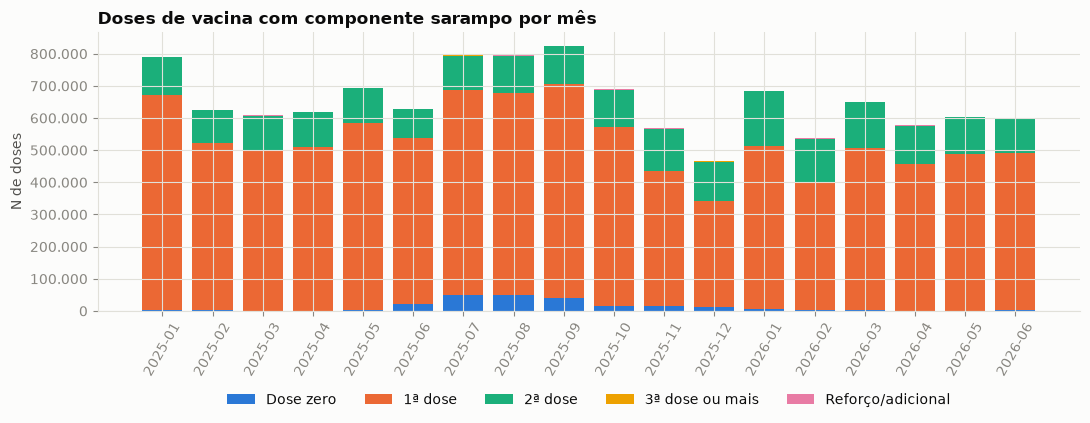

In [2]:
ordem_dose = ["Dose zero", "1ª dose", "2ª dose", "3ª dose ou mais", "Reforço/adicional"]
m = uf_mes.pivot_table(index="ano_mes", columns="dose_grupo", values="doses", aggfunc="sum").reindex(columns=ordem_dose).fillna(0)
fig, ax = plt.subplots(figsize=(11, 4.5))
base = np.zeros(len(m))
for cor, col in zip(CATEGORICAL, m.columns):
    ax.bar(m.index, m[col], bottom=base, label=col, color=cor)
    base += m[col].values
titulo(ax, "Doses de vacina com componente sarampo por mês")
ax.set_ylabel("N de doses"); milhar(ax)
ax.tick_params(axis="x", rotation=60)
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.25))
plt.tight_layout(); plt.show()

## 3. Série diária (média móvel de 7 dias)
Picos e vales semanais (fins de semana, feriados) somem na média móvel e deixam a tendência e as campanhas visíveis.

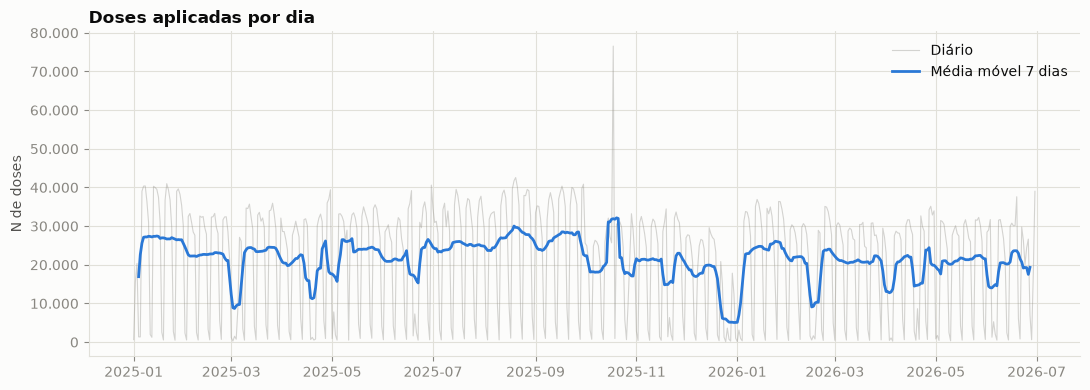

Maior média semanal: 32,138 doses/dia, em torno de 20/10/2025


In [3]:
d = dia.groupby("data_vacinacao")["doses"].sum().asfreq("D").fillna(0)
mm = d.rolling(7, center=True).mean()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(d.index, d.values, color=MUTED, alpha=0.35, linewidth=0.8, label="Diário")
ax.plot(mm.index, mm.values, color=BLUE, linewidth=2, label="Média móvel 7 dias")
titulo(ax, "Doses aplicadas por dia")
ax.set_ylabel("N de doses"); milhar(ax); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print(f"Maior média semanal: {mm.max():,.0f} doses/dia, em torno de {mm.idxmax():%d/%m/%Y}")

## 4. Tipo de vacina
A tríplice viral (SCR) domina; a tetra viral (SCRV) cobre a dose aos 15 meses.

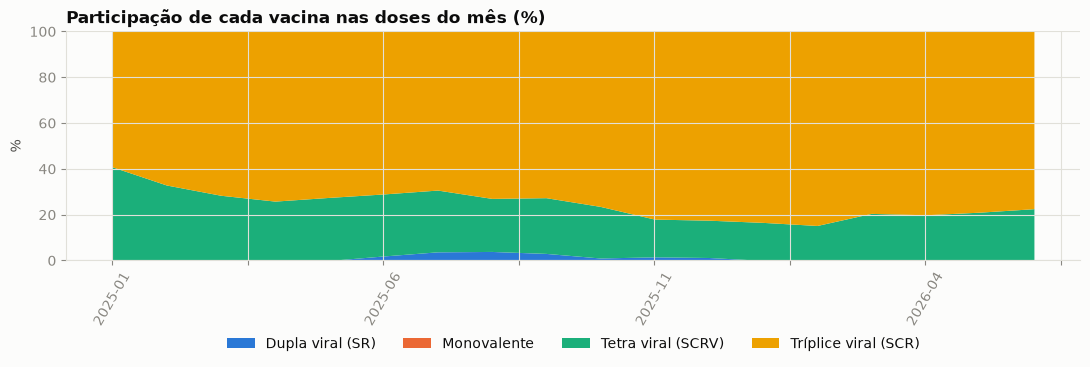

In [4]:
t = uf_mes.pivot_table(index="ano_mes", columns="vacina_tipo", values="doses", aggfunc="sum").fillna(0)
t = t.div(t.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(11, 4))
t.plot.area(ax=ax, color=CATEGORICAL[: t.shape[1]], linewidth=0)
titulo(ax, "Participação de cada vacina nas doses do mês (%)")
ax.set_ylabel("%"); ax.set_xlabel(""); ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=60)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.28))
plt.tight_layout(); plt.show()

## 5. Geografia: UF de residência do paciente

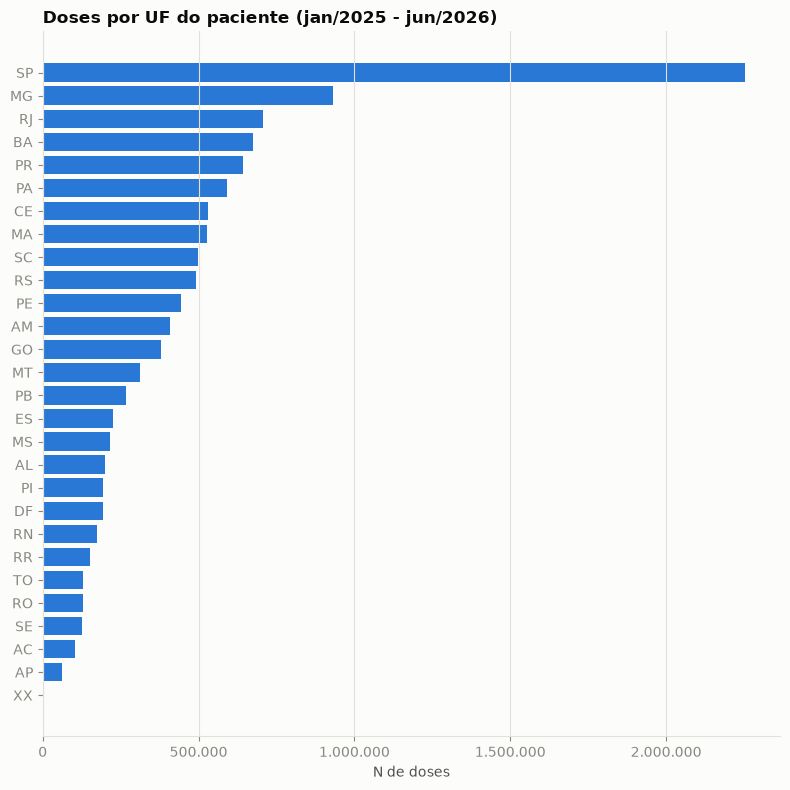

In [5]:
uf = uf_mes.groupby("uf_paciente")["doses"].sum().sort_values()
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(uf.index.astype(str), uf.values, color=BLUE)
titulo(ax, "Doses por UF do paciente (jan/2025 - jun/2026)")
ax.set_xlabel("N de doses"); milhar(ax, "x"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### Calendário por UF
Cada célula é o volume do mês **relativo à média da própria UF** (100 = média). Assim se comparam ritmos entre UFs grandes e pequenas; células escuras = mês mais forte.

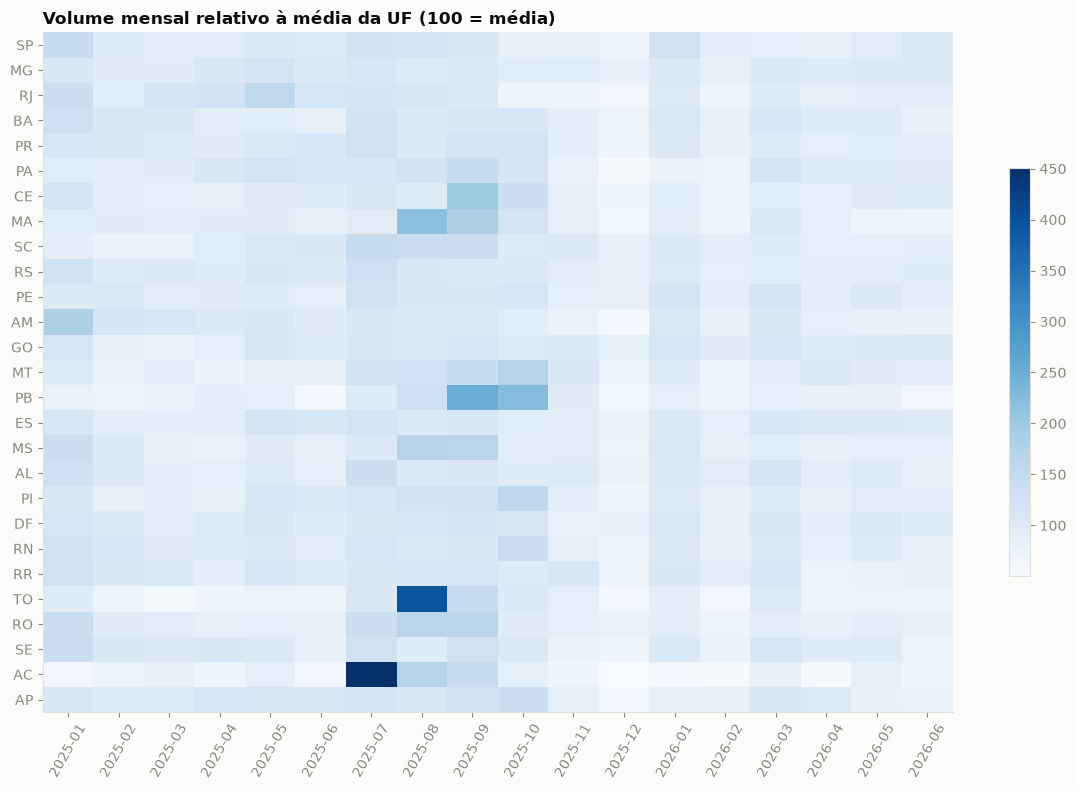

In [6]:
h = uf_mes.pivot_table(index="uf_paciente", columns="ano_mes", values="doses", aggfunc="sum").fillna(0)
h = h[h.sum(axis=1) > 5000]
rel = h.div(h.mean(axis=1), axis=0) * 100
rel = rel.loc[h.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(rel.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(rel.shape[1])); ax.set_xticklabels(rel.columns, rotation=60)
ax.set_yticks(range(rel.shape[0])); ax.set_yticklabels(rel.index)
ax.grid(False)
titulo(ax, "Volume mensal relativo à média da UF (100 = média)")
fig.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout(); plt.show()

## 6. Perfil demográfico

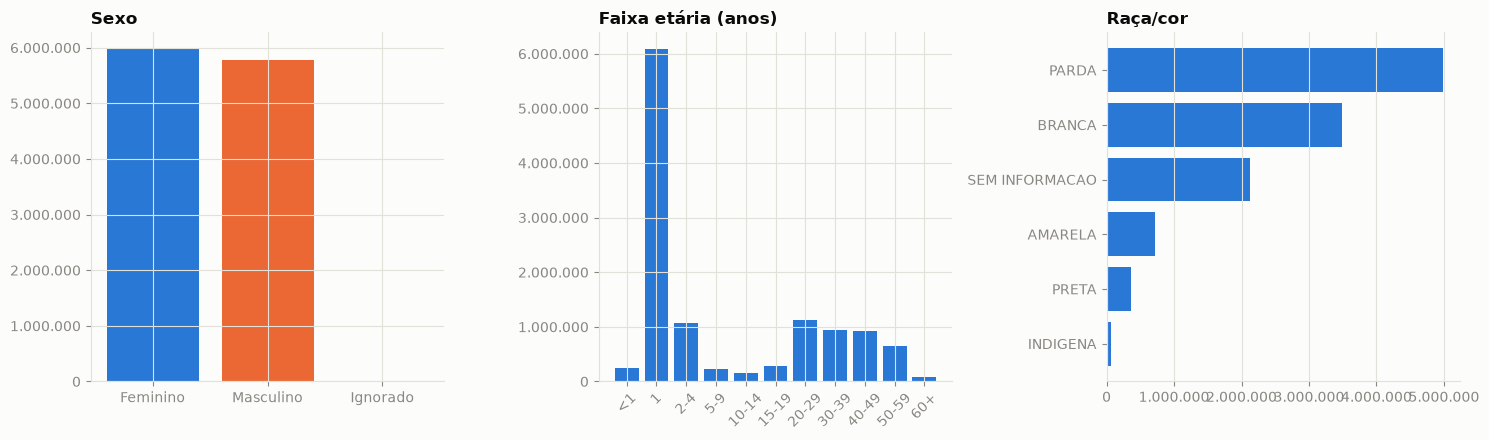

faixa_etaria
<1       2.10
1       51.80
2-4      9.10
5-9      1.90
10-14    1.30
15-19    2.30
20-29    9.60
30-39    8.00
40-49    7.80
50-59    5.50
60+      0.70
Name: % das doses, dtype: float64

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sx = perfil.groupby("sexo_paciente")["doses"].sum().sort_values(ascending=False)
axes[0].bar(sx.index, sx.values, color=CATEGORICAL[: len(sx)]); titulo(axes[0], "Sexo"); milhar(axes[0])
ordem = ["<1", "1", "2-4", "5-9", "10-14", "15-19", "20-29", "30-39", "40-49", "50-59", "60+"]
fx = perfil.groupby("faixa_etaria")["doses"].sum().reindex(ordem)
axes[1].bar(fx.index, fx.values, color=BLUE); titulo(axes[1], "Faixa etária (anos)"); milhar(axes[1])
axes[1].tick_params(axis="x", rotation=45)
rc = perfil.groupby("raca_cor_paciente")["doses"].sum().sort_values()
axes[2].barh(rc.index, rc.values, color=BLUE); titulo(axes[2], "Raça/cor"); milhar(axes[2], "x"); axes[2].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
(fx / fx.sum() * 100).round(1).rename("% das doses")

### Idade e dose
Doses por idade simples, por número de dose: a 1ª dose se concentra em 1 ano (12 meses) e a 2ª, em 1-2 anos (15 meses/tetra viral); a cauda adulta indica bloqueios e campanhas de atualização.

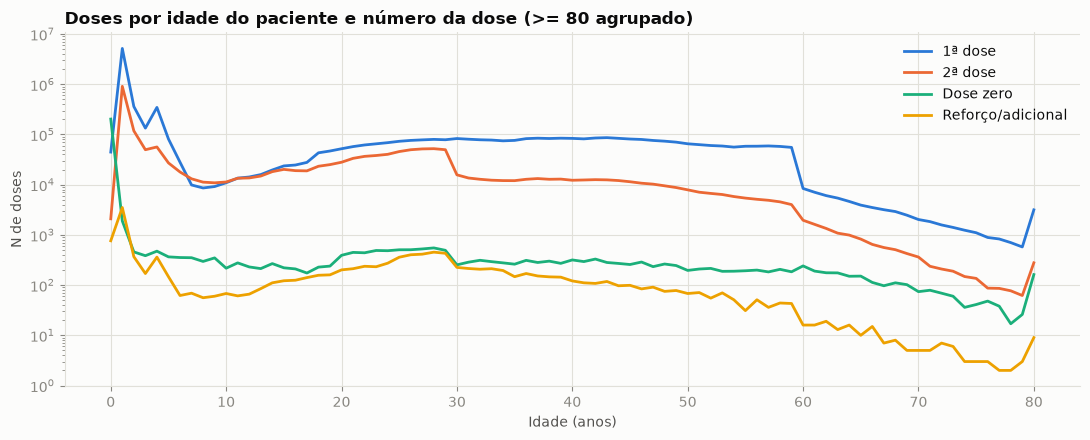

In [8]:
ia = idade.assign(idade=idade["idade_paciente"].clip(upper=80)).pivot_table(
    index="idade", columns="dose_grupo", values="doses", aggfunc="sum").fillna(0)
fig, ax = plt.subplots(figsize=(11, 4.5))
for cor, col in zip(CATEGORICAL, [c for c in ["1ª dose", "2ª dose", "Dose zero", "Reforço/adicional"] if c in ia.columns]):
    ax.plot(ia.index, ia[col], label=col, color=cor, linewidth=2)
titulo(ax, "Doses por idade do paciente e número da dose (>= 80 agrupado)")
ax.set_xlabel("Idade (anos)"); ax.set_ylabel("N de doses"); milhar(ax); ax.set_yscale("log")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 7. Evolução dos KPIs
Além do volume, o mix do mês mostra mudanças de perfil: menos crianças de 1-4 anos e menos doses de rotina indicam campanhas/bloqueios com público mais amplo.

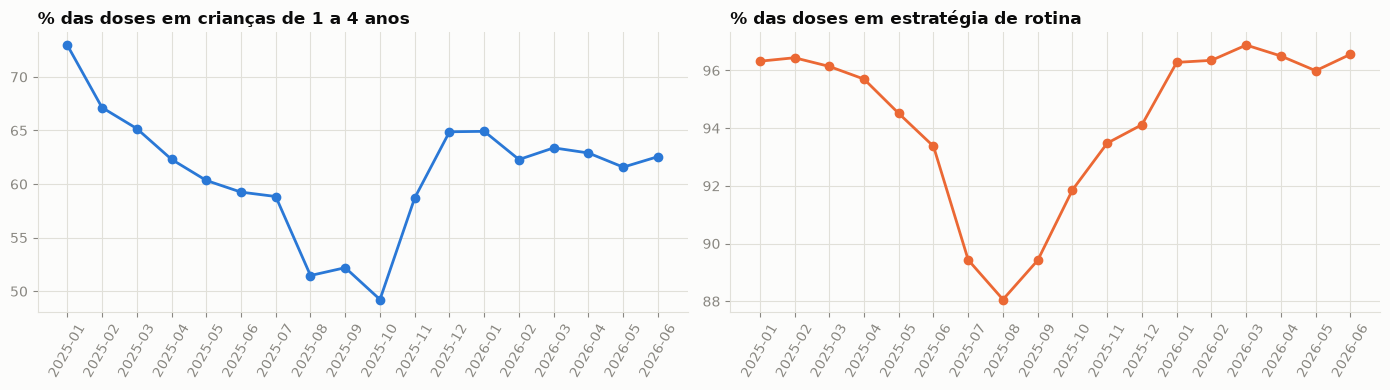

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(kpi["ano_mes"], kpi["pct_criancas_1a4"], color=BLUE, linewidth=2, marker="o")
titulo(axes[0], "% das doses em crianças de 1 a 4 anos"); axes[0].tick_params(axis="x", rotation=60)
axes[1].plot(kpi["ano_mes"], kpi["pct_rotina"], color=CATEGORICAL[1], linewidth=2, marker="o")
titulo(axes[1], "% das doses em estratégia de rotina"); axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

## Leituras
- O volume mensal oscila entre ~465 mil e ~825 mil doses; jul-set/2025 concentram os meses mais fortes, seguidos de queda em nov-dez.
- A participação da rotina cai de ~96% para ~88% no meio de 2025 e recupera depois, sinal de ações extras (campanhas/intensificação) naquele período.
- A gold conta **doses**. Para **cobertura** é preciso dividir pelo público-alvo (SINASC/IBGE por município), o próximo passo natural.